# Per-Time-Bin Decoding (no stimulus averaging)

Same overall procedure as `File_cleaned_layers.ipynb`, but every temporal
bin within every trial is an **individual sample**. This:

- Preserves temporal structure inside each trial
- Increases sample count ~50x (enough for t-SNE / UMAP / CEBRA to be meaningful)
- Lets CEBRA actually see a time series (its real use case)
- Forces cross-validation to group by trial (`GroupKFold`) so frames from the
  same trial cannot leak across folds
- Evaluates classifiers in the **full PCA-50 space**, not on 2-D embeddings


imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import defaultdict, Counter
import warnings, h5py
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, GroupKFold
from sklearn.pipeline import Pipeline

from scipy.stats import ttest_1samp

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

try:
    import cebra
    CEBRA_AVAILABLE = True
except ImportError:
    CEBRA_AVAILABLE = False

%load_ext autoreload
%autoreload 2
import microns_datacleaner as mic
import microns_datacleaner.filters as fl

In [2]:
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 12, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False, 'savefig.bbox': 'tight',
})
SEED    = 42
SESSION = '9_4'

# === Temporal binning ===
# Each trial has many frames; we bin BIN_SIZE consecutive frames together
# (mean inside the bin -> denoising) and emit one sample per bin.
BIN_SIZE = 5      # frames per bin
MIN_BINS = 2      # drop trials shorter than this many bins

# === Pipeline knobs ===
N_PCS_FOR_CLF   = 50    # classifier evaluated in this PCA space
N_PCS_FOR_TSNE  = 50    # input to t-SNE / UMAP
N_CV_SPLITS     = 5
N_SHUFFLES      = 50


metadata, filter (identical to original)

In [3]:
from pathlib import Path
import os

# Offline/local-data setup.
# Do NOT call MicronsDataCleaner(...), because its constructor initializes CAVEclient online.
# Instead, create the object without __init__, configure table names, and read existing local CSVs.
DATA_DIR = Path("data")
VERSION = 1718

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Expected a local data/ folder in the notebook working directory, but it was not found."
    )

cleaner = mic.MicronsDataCleaner.__new__(mic.MicronsDataCleaner)
cleaner.version = VERSION
cleaner.datadir = str(DATA_DIR)
cleaner.homedir = Path().resolve()
cleaner.data_storage = str(cleaner.homedir / cleaner.datadir / str(cleaner.version))

# This only reads the package YAML config; it does not contact the internet for download_policy='minimum'.
cleaner._configure_download_tables(VERSION, download_policy="minimum", extra_tables=[])

required_tables = [
    cleaner.tables["nucleus"],
    cleaner.tables["celltype"],
    cleaner.tables["proofreading"],
    cleaner.tables["brain_areas"],
]
if "func_props" in cleaner.tables and cleaner.tables["func_props"] is not None:
    required_tables.append(cleaner.tables["func_props"])
required_tables += list(cleaner.info_to_correct.keys())
required_files = [f"{t}.csv" for t in required_tables if t is not None]

# The package normally expects files in data/1718/raw/.
# This search also supports data/raw/ if your local folder was copied in a flatter format.
candidate_raw_dirs = [
    DATA_DIR / str(VERSION) / "raw",
    DATA_DIR / "raw",
]

raw_dir = None
for d in candidate_raw_dirs:
    if d.exists():
        existing = {x.name for x in d.glob("*.csv")}
        if all(fname in existing for fname in required_files):
            raw_dir = d
            break

if raw_dir is None:
    debug = []
    for d in candidate_raw_dirs:
        if d.exists():
            debug.append(f"{d}: {[x.name for x in d.glob('*.csv')][:20]}")
        else:
            debug.append(f"{d}: MISSING")
    raise FileNotFoundError(
        "Could not find the local MICrONS raw CSV files needed by microns_datacleaner.\n"
        "Expected all of these files:\n"
        f"{required_files}\n\n"
        "Checked:\n" + "\n".join(debug)
    )

# process_nucleus_data reads from f'{cleaner.data_storage}/raw/...'
# so data_storage must be the parent folder of raw/.
cleaner.data_storage = str(raw_dir.parent)

# IMPORTANT: no cleaner.download_nucleus_data() here.
units, segments = cleaner.process_nucleus_data(functional_data="best_only")

v1_neurons = fl.filter_neurons(units, brain_area="V1", proofread="ax_clean", tuning="matched")
print(f"V1 neurons (proofread + matched tuning): {len(v1_neurons)}")

# Locate the functional HDF5 file locally.
h5_candidates = [
    Path("microns.h5"),
    DATA_DIR / "microns.h5",
    DATA_DIR / "functional" / "microns_functional.h5",
]
MICRONS_H5_PATH = next((p for p in h5_candidates if p.exists()), None)
if MICRONS_H5_PATH is None:
    raise FileNotFoundError(
        "Could not find the functional HDF5 file. Expected one of:\n"
        + "\n".join(str(p) for p in h5_candidates)
    )

with h5py.File(MICRONS_H5_PATH, "r") as f:
    session_unit_ids = f["sessions"][SESSION]["meta"]["unit_ids"][:]

v1_with_uid = v1_neurons.dropna(subset=["unit_id"]).copy()
v1_with_uid["unit_id_int"] = v1_with_uid["unit_id"].astype(int)
trusted_unit_ids = set(v1_with_uid["unit_id_int"].values)
keep_neuron_cols = np.where(np.isin(session_unit_ids, list(trusted_unit_ids)))[0]
print(f"Trusted neurons in session: {len(keep_neuron_cols)} / {len(session_unit_ids)}")

uid_to_meta = v1_with_uid.drop_duplicates(subset=["unit_id_int"]).set_index("unit_id_int")

def _meta(uid, col):
    if uid in uid_to_meta.index:
        v = uid_to_meta.at[uid, col]
        return str(v) if not isinstance(v, str) else v
    return "unknown"

trusted_meta = pd.DataFrame([
    {
        "unit_id": int(uid),
        "layer": _meta(uid, "layer"),
        "classification_system": _meta(uid, "classification_system"),
    }
    for uid in session_unit_ids[keep_neuron_cols]
])
print(trusted_meta["layer"].value_counts().to_string())


Transform positions:   0%|          | 0/94014 [00:00<?, ?it/s]

Transform positions:   7%|▋         | 6861/94014 [00:00<00:01, 68603.52it/s]

Transform positions:  15%|█▍        | 13739/94014 [00:00<00:01, 68704.28it/s]

Transform positions:  22%|██▏       | 20647/94014 [00:00<00:01, 68871.44it/s]

Transform positions:  29%|██▉       | 27537/94014 [00:00<00:00, 68878.66it/s]

...

Transform positions:  81%|████████  | 75736/94014 [00:01<00:00, 68658.49it/s]

Transform positions:  88%|████████▊ | 82638/94014 [00:01<00:00, 68766.36it/s]

Transform positions:  95%|█████████▌| 89515/94014 [00:01<00:00, 68635.41it/s]

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 68683.02it/s]

V1 neurons (proofread + matched tuning): 728
Trusted neurons in session: 579 / 7855
layer
L4      257
L2/3    220
L5       89
L6       12
L1        1


## Per-bin sample extraction

Replaces the single `mean(axis=1)` collapse in the original. Each row of
`R_matrix` is now a single time-bin of a single trial — labelled by the
stimulus type of that trial, and tagged with `trial_id` so we can do
group-wise cross-validation.


In [4]:
funcreader = mic.MicronsFunctionalReader(path=str(MICRONS_H5_PATH))
hashes     = funcreader.get_hashes_by_session(SESSION)

print(f'Trials in session: {len(hashes)}')
print('Stimulus types:')
for k, v in sorted(Counter(funcreader.get_video_type(h) for h in hashes).items(),
                   key=lambda x: -x[1]):
    print(f'  {k:22s}: {v:4d}')


Trials in session: 464
Stimulus types:
  Clip                  :  384
  Monet2                :   40
  Trippy                :   40


In [5]:
# --- Per-bin extraction loop ---
bins_resp, bins_type, bins_hash, bins_trial, bins_t = [], [], [], [], []
n_failed = 0
n_trials_used = 0

print(f'Extracting bins (BIN_SIZE={BIN_SIZE} frames)...')
for trial_idx, h in enumerate(hashes):
    stype = funcreader.get_video_type(h)
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            n_failed += 1
            continue
        resp = r['responses'][keep_neuron_cols, :]            # (n_neurons, n_frames)
        n_frames = resp.shape[1]
        n_bins   = n_frames // BIN_SIZE
        if n_bins < MIN_BINS:
            continue
        # (n_bins, n_neurons): mean within each consecutive BIN_SIZE-frame window
        binned = (resp[:, :n_bins * BIN_SIZE]
                  .reshape(resp.shape[0], n_bins, BIN_SIZE)
                  .mean(axis=2)
                  .T)
        for b in range(n_bins):
            bins_resp.append(binned[b])
            bins_type.append(stype)
            bins_hash.append(h)
            bins_trial.append(trial_idx)
            bins_t.append(b)
        n_trials_used += 1
    except Exception:
        n_failed += 1

R_matrix   = np.array(bins_resp)                 # (n_bins_total, n_neurons)
labels_raw = np.array(bins_type)
hash_ids   = np.array(bins_hash)
trial_ids  = np.array(bins_trial)
time_idx   = np.array(bins_t)

print(f'\nTrials used:   {n_trials_used}  (skipped: {n_failed})')
print(f'Bins/sample:    {len(R_matrix)}')
print(f'R_matrix shape: {R_matrix.shape}')
print('\nBins per stimulus type:')
for k, v in sorted(Counter(labels_raw).items(), key=lambda x: -x[1]):
    print(f'  {k:22s}: {v:5d}')


Extracting bins (BIN_SIZE=5 frames)...



Trials used:   464  (skipped: 0)
Bins/sample:    7520
R_matrix shape: (7520, 579)

Bins per stimulus type:
  Clip                  :  5760
  Monet2                :   880
  Trippy                :   880


preprocessing

In [6]:
# Drop neurons with too many NaNs across all bins.
# This is unsupervised feature filtering. For a maximally strict analysis,
# this could also be moved inside each CV fold, but it is not the main leakage
# causing the CEBRA issue.
nan_frac     = np.isnan(R_matrix).mean(axis=0)
keep_neurons = nan_frac < 0.10

R_clean = R_matrix[:, keep_neurons].copy()
trusted_meta_clean = trusted_meta[keep_neurons].reset_index(drop=True)

print(f'Neurons retained: {keep_neurons.sum()} / {R_matrix.shape[1]}')

# Drop bins that are totally flat across neurons.
# This is a per-sample filter, not a train/test statistic.
active = np.nanstd(R_clean, axis=1) > 1e-6

R_clean   = R_clean[active]
labels    = labels_raw[active]
hash_ids  = hash_ids[active]
trial_ids = trial_ids[active]
time_idx  = time_idx[active]

print(f'Bins after activity filter: {active.sum()} / {len(active)}')

# Global imputed/scaled version is for visualization only.
# Do NOT use R_scaled/R_pca for quantitative decoding.
viz_imputer = SimpleImputer(strategy='mean')
viz_scaler  = StandardScaler()

R_viz    = viz_imputer.fit_transform(R_clean)
R_scaled = viz_scaler.fit_transform(R_viz)

print(f'\nFinal raw feature matrix for modeling: {R_clean.shape}')
print(f'Visualization matrix: {R_scaled.shape}')


Neurons retained: 579 / 579
Bins after activity filter: 7520 / 7520

Final raw feature matrix for modeling: (7520, 579)
Visualization matrix: (7520, 579)


In [7]:
unique_labels = sorted(set(labels))
n_types       = len(unique_labels)
palette       = plt.cm.get_cmap('tab10', n_types)
label_to_color = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}
le            = LabelEncoder()
y             = le.fit_transform(labels)
counts        = {lbl: int((labels == lbl).sum()) for lbl in unique_labels}
majority_frac = max(counts.values()) / len(labels)
chance_level  = 1.0 / n_types
legend_patches = [Patch(color=label_to_color[l], label=l) for l in unique_labels]

print(f'Classes: {n_types}  |  chance = {chance_level:.3f}  |  majority = {majority_frac:.3f}')
for lbl, n in counts.items():
    print(f'  {lbl:22s}  n={n:5d}  ({100*n/len(labels):.1f}%)')
print(f'\nUnique trials: {len(np.unique(trial_ids))}  '
      f'(used as CV groups)')


Classes: 3  |  chance = 0.333  |  majority = 0.766
  Clip                    n= 5760  (76.6%)
  Monet2                  n=  880  (11.7%)
  Trippy                  n=  880  (11.7%)

Unique trials: 464  (used as CV groups)


## PCA

The big change here is that we now have thousands of samples instead of
hundreds, so the leading PCs are far better estimated.


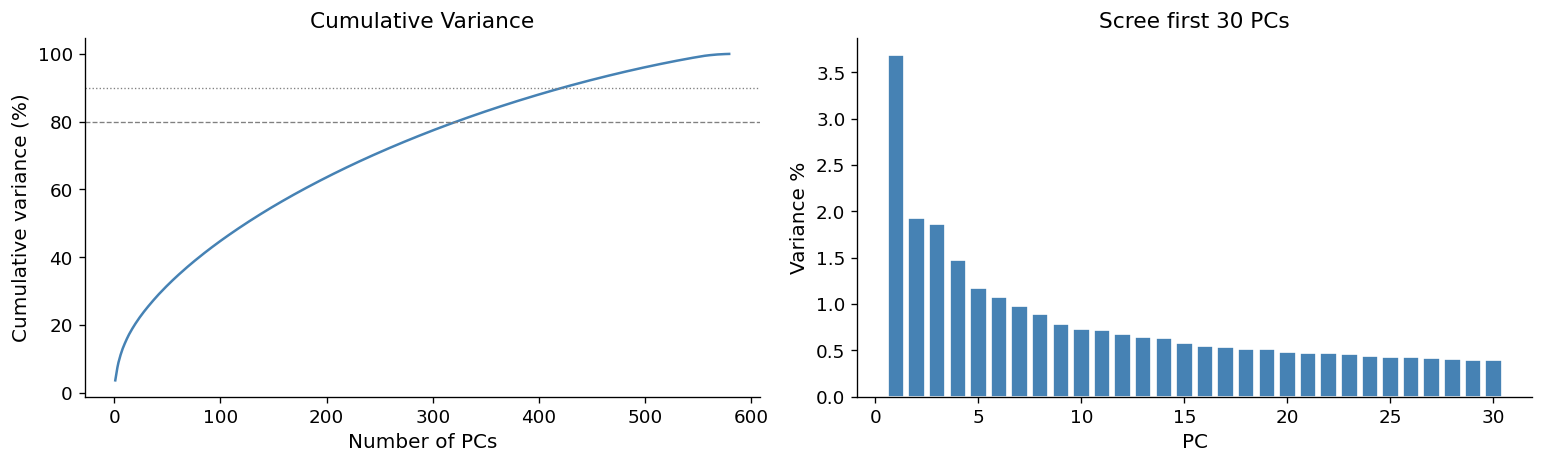

PCs for 80% var: 322   PCs for 90% var: 422
PC1+PC2: 5.62%
Participation ratio: 212.0
Total variance explained by full fitted spectrum: 100.00%


In [8]:
# Descriptive PCA on the full dataset.
# This is for visualization and variance diagnostics only.
# Quantitative decoding below will fit PCA inside each CV fold.

pca = PCA(n_components=None, svd_solver='full')
R_pca = pca.fit_transform(R_scaled)

ev = pca.explained_variance_ratio_
cumvar = np.cumsum(ev)
n_pcs = len(ev)

participation_ratio = 1.0 / np.sum(ev ** 2)

def pcs_needed(cumvar, threshold):
    if cumvar[-1] < threshold:
        return f'>{len(cumvar)}'
    return str(int(np.searchsorted(cumvar, threshold) + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, n_pcs + 1), cumvar * 100, color='steelblue')
axes[0].set_xlabel('Number of PCs')
axes[0].set_ylabel('Cumulative variance (%)')
axes[0].axhline(80, color='gray', ls='--', lw=0.8)
axes[0].axhline(90, color='gray', ls=':',  lw=0.8)
axes[0].set_title('Cumulative Variance')

n_show = min(30, n_pcs)
axes[1].bar(
    np.arange(1, n_show + 1),
    ev[:n_show] * 100,
    color='steelblue',
    edgecolor='white',
)
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Variance %')
axes[1].set_title(f'Scree first {n_show} PCs')

plt.tight_layout()
plt.savefig('fig_ts_pca_variance.png', dpi=150)
plt.show()

n80 = pcs_needed(cumvar, 0.80)
n90 = pcs_needed(cumvar, 0.90)

pc12 = cumvar[min(1, len(cumvar) - 1)] * 100

print(f'PCs for 80% var: {n80}   PCs for 90% var: {n90}')
print(f'PC1+PC2: {pc12:.2f}%')
print(f'Participation ratio: {participation_ratio:.1f}')
print(f'Total variance explained by full fitted spectrum: {cumvar[-1] * 100:.2f}%')


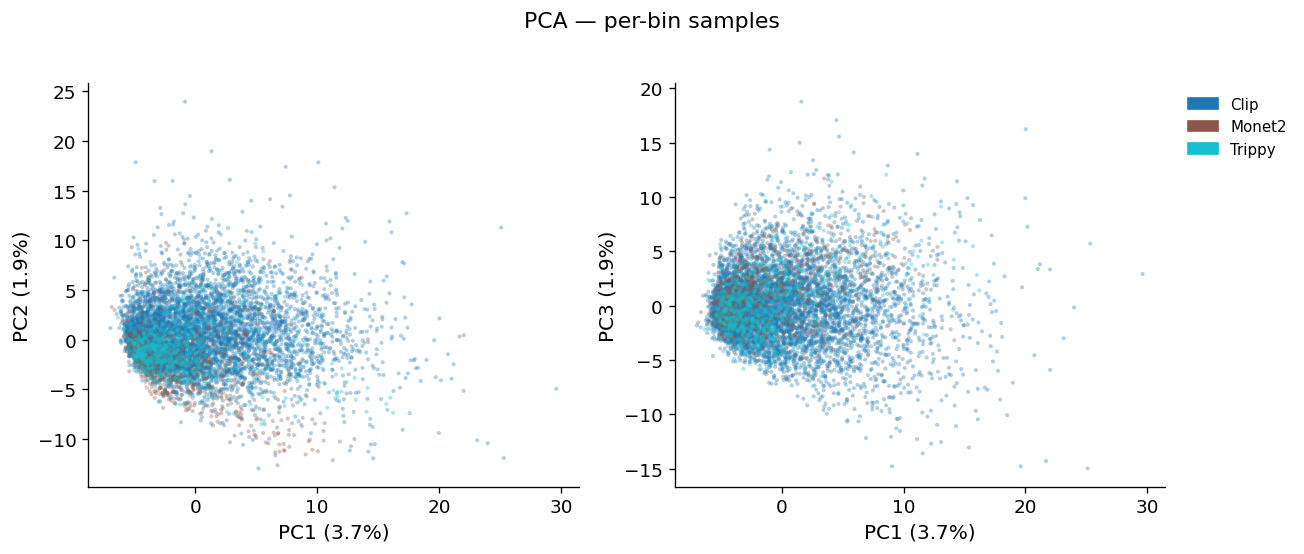

In [9]:
# Scatter coloured by class
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for xi, yi, ax in [(0,1,axes[0]), (0,2,axes[1])]:
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(R_pca[m,xi], R_pca[m,yi],
                   color=label_to_color[lbl], alpha=0.35, s=6, edgecolors='none')
    ax.set_xlabel(f'PC{xi+1} ({ev[xi]*100:.1f}%)')
    ax.set_ylabel(f'PC{yi+1} ({ev[yi]*100:.1f}%)')
axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.suptitle('PCA — per-bin samples', y=1.02)
plt.tight_layout(); plt.savefig('fig_ts_pca_scatter.png', dpi=150); plt.show()


## t-SNE and UMAP

Subsample for speed (t-SNE/UMAP scale poorly past ~10k points).


In [10]:
rng = np.random.default_rng(SEED)
SUB_N = min(8000, len(R_pca))
sub_idx = rng.choice(len(R_pca), size=SUB_N, replace=False)
sub_idx.sort()

R_pca_sub  = R_pca[sub_idx, :N_PCS_FOR_TSNE]
labels_sub = labels[sub_idx]
y_sub      = y[sub_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED,
            max_iter=1000, learning_rate='auto', init='pca')
R_tsne = tsne.fit_transform(R_pca_sub)

R_umap = None
if UMAP_AVAILABLE:
    R_umap = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                       random_state=SEED).fit_transform(R_pca_sub)


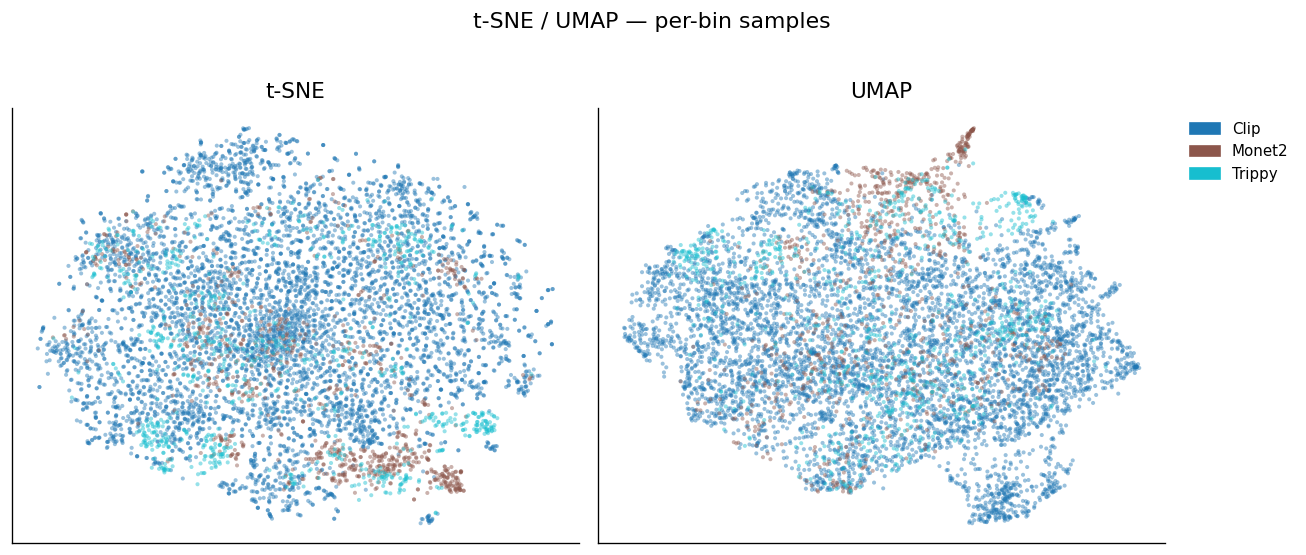

In [11]:
fig, axes = plt.subplots(1, 2 if R_umap is not None else 1,
                         figsize=(11 if R_umap is not None else 6, 4.5))
if R_umap is None: axes = [axes]
for ax, name, emb in [(axes[0], 't-SNE', R_tsne)] + (
    [(axes[1], 'UMAP', R_umap)] if R_umap is not None else []):
    for lbl in unique_labels:
        m = labels_sub == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.45, s=6, edgecolors='none')
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.suptitle('t-SNE / UMAP — per-bin samples', y=1.02)
plt.tight_layout(); plt.savefig('fig_ts_tsne_umap.png', dpi=150); plt.show()


## CEBRA — fed as a time series

Per-trial neural traces are concatenated in time, with stimulus type as the
auxiliary discrete label. This is what `offset10-model` is designed for.


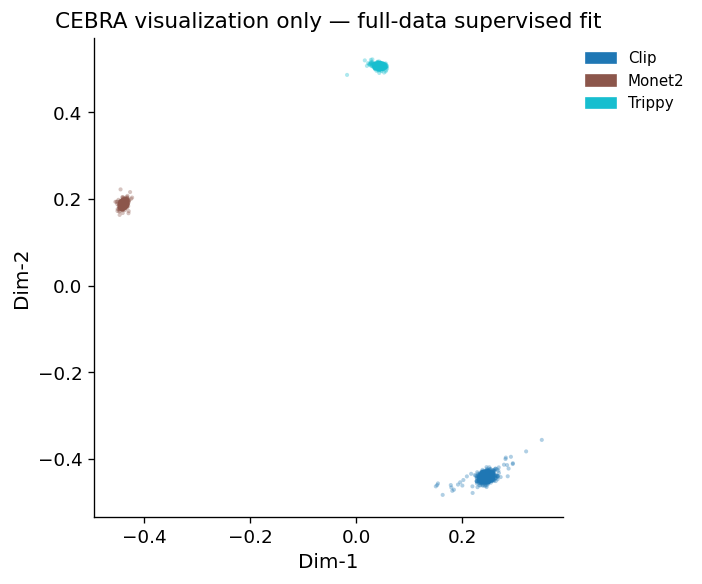

In [12]:
# CEBRA visualization only.
#
# Important:
# This fits supervised CEBRA on the full dataset using the stimulus labels.
# Therefore, this embedding must NOT be used for quantitative decoding.
# Proper fold-local CEBRA decoding is implemented in the evaluation cell below.

R_cebra_viz = None

CEBRA_PARAMS = dict(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=4000,
    distance='cosine',
    conditional='discrete',
    device='cpu',
    verbose=False,
)

if CEBRA_AVAILABLE:
    try:
        order = np.lexsort((time_idx, trial_ids))
        R_ordered = R_scaled[order].astype(np.float32)
        y_ordered = y[order].astype(np.int64)

        cb_viz = cebra.CEBRA(**CEBRA_PARAMS)
        cb_viz.fit(R_ordered, y_ordered)

        R_cebra_ord = cb_viz.transform(R_ordered)

        inv = np.empty_like(order)
        inv[order] = np.arange(len(order))
        R_cebra_viz = R_cebra_ord[inv]

        fig, ax = plt.subplots(figsize=(6, 5))
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(
                R_cebra_viz[m, 0],
                R_cebra_viz[m, 1],
                color=label_to_color[lbl],
                alpha=0.35,
                s=6,
                edgecolors='none',
            )

        ax.set_title('CEBRA visualization only — full-data supervised fit')
        ax.set_xlabel('Dim-1')
        ax.set_ylabel('Dim-2')
        ax.legend(
            handles=legend_patches,
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=9,
        )

        plt.tight_layout()
        plt.savefig('fig_ts_cebra_viz_only.png', dpi=150)
        plt.show()

    except Exception as e:
        print(f'CEBRA visualization failed: {e}')
        R_cebra_viz = None
else:
    print('CEBRA not installed')

## Quantitative evaluation

**Key change vs the original**: the classifier is evaluated in the
full PCA-`N_PCS_FOR_CLF`-dimensional space, not in the 2-D embedding.
2-D t-SNE / UMAP coordinates are visualization-only; their pairwise
distances are not metric-faithful, so it is meaningless to feed them to a
linear classifier.

We use `GroupKFold(groups=trial_ids)` so no fold contains bins from a
trial that also appears in the training set. Without this, the classifier
trivially memorizes within-trial autocorrelation.


In [13]:
gkf = GroupKFold(n_splits=N_CV_SPLITS)

def make_logreg():
    return LogisticRegression(
        max_iter=2000,
        C=1.0,
        random_state=SEED,
        class_weight='balanced',
        n_jobs=-1,
    )

def make_pca_logreg_pipeline(n_components):
    return Pipeline([
        ('impute', SimpleImputer(strategy='mean')),
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=n_components, random_state=SEED)),
        ('clf', make_logreg()),
    ])

def evaluate_sklearn_model_cv(name, model, X, y, groups):
    bal = cross_val_score(
        model,
        X,
        y,
        cv=gkf,
        groups=groups,
        scoring='balanced_accuracy',
        n_jobs=-1,
    )

    f1 = cross_val_score(
        model,
        X,
        y,
        cv=gkf,
        groups=groups,
        scoring='f1_macro',
        n_jobs=-1,
    )

    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=gkf,
        groups=groups,
        n_jobs=-1,
    )

    print(
        f'  {name:14s}  bal_acc = {bal.mean():.4f} ± {bal.std():.4f}'
        f'   F1 = {f1.mean():.4f} ± {f1.std():.4f}'
    )

    return {
        'bal': bal,
        'f1': f1,
        'y_pred': y_pred,
    }

def evaluate_cebra_groupcv(X_raw, y, groups, time_idx):
    y_pred = np.full_like(y, fill_value=-1)

    fold_bal = []
    fold_f1 = []

    splits = list(gkf.split(X_raw, y, groups=groups))

    for fold_i, (train_idx, test_idx) in enumerate(splits, start=1):
        print(f'  CEBRA fold {fold_i}/{len(splits)}')

        # Preprocessing fit only on training fold.
        imputer = SimpleImputer(strategy='mean')
        scaler = StandardScaler()

        X_train = imputer.fit_transform(X_raw[train_idx])
        X_test  = imputer.transform(X_raw[test_idx])

        X_train = scaler.fit_transform(X_train).astype(np.float32)
        X_test  = scaler.transform(X_test).astype(np.float32)

        y_train = y[train_idx].astype(np.int64)
        y_test  = y[test_idx].astype(np.int64)

        # Sort only the training fold so CEBRA sees temporally ordered chunks.
        train_order = np.lexsort((time_idx[train_idx], groups[train_idx]))

        X_train_ordered = X_train[train_order]
        y_train_ordered = y_train[train_order]

        cb = cebra.CEBRA(**CEBRA_PARAMS)
        cb.fit(X_train_ordered, y_train_ordered)

        # Transform train and test without using test labels.
        Z_train = cb.transform(X_train)
        Z_test  = cb.transform(X_test)

        clf_fold = make_logreg()
        clf_fold.fit(Z_train, y_train)

        pred = clf_fold.predict(Z_test)
        y_pred[test_idx] = pred

        fold_bal.append(balanced_accuracy_score(y_test, pred))
        fold_f1.append(f1_score(y_test, pred, average='macro'))

    if np.any(y_pred < 0):
        raise RuntimeError('Some samples did not receive CEBRA predictions.')

    fold_bal = np.array(fold_bal)
    fold_f1 = np.array(fold_f1)

    return {
        'bal': fold_bal,
        'f1': fold_f1,
        'y_pred': y_pred,
    }

models = {
    'PCA-2D': make_pca_logreg_pipeline(2),
    f'PCA-{N_PCS_FOR_CLF}D': make_pca_logreg_pipeline(N_PCS_FOR_CLF),
}

cv_results = {}

print('Cross-validated balanced accuracy, GroupKFold by trial')
print(f'  chance={chance_level:.3f}   majority={majority_frac:.3f}\n')

for name, model in models.items():
    cv_results[name] = evaluate_sklearn_model_cv(
        name=name,
        model=model,
        X=R_clean,
        y=y,
        groups=trial_ids,
    )

if CEBRA_AVAILABLE:
    try:
        name = 'CEBRA-8D'
        cv_results[name] = evaluate_cebra_groupcv(
            X_raw=R_clean,
            y=y,
            groups=trial_ids,
            time_idx=time_idx,
        )

        bal = cv_results[name]['bal']
        f1 = cv_results[name]['f1']

        print(
            f'  {name:14s}  bal_acc = {bal.mean():.4f} ± {bal.std():.4f}'
            f'   F1 = {f1.mean():.4f} ± {f1.std():.4f}'
        )

    except Exception as e:
        print(f'Fold-local CEBRA evaluation failed: {e}')
else:
    print('Skipping CEBRA evaluation because CEBRA is not installed.')

# Keep the original "scores" dict shape for downstream cells.
scores = {
    name: (
        result['bal'].mean(),
        result['bal'].std(),
        result['f1'].mean(),
        result['f1'].std(),
    )
    for name, result in cv_results.items()
}

# Leakage-free predictions for confusion matrices.
predictions = {
    name: result['y_pred']
    for name, result in cv_results.items()
}

Cross-validated balanced accuracy, GroupKFold by trial
  chance=0.333   majority=0.766



  PCA-2D          bal_acc = 0.4573 ± 0.0375   F1 = 0.3776 ± 0.0283


  PCA-50D         bal_acc = 0.8125 ± 0.0212   F1 = 0.7401 ± 0.0213
  CEBRA fold 1/5


  CEBRA fold 2/5


  CEBRA fold 3/5


  CEBRA fold 4/5


  CEBRA fold 5/5


  CEBRA-8D        bal_acc = 0.9000 ± 0.0270   F1 = 0.8960 ± 0.0172


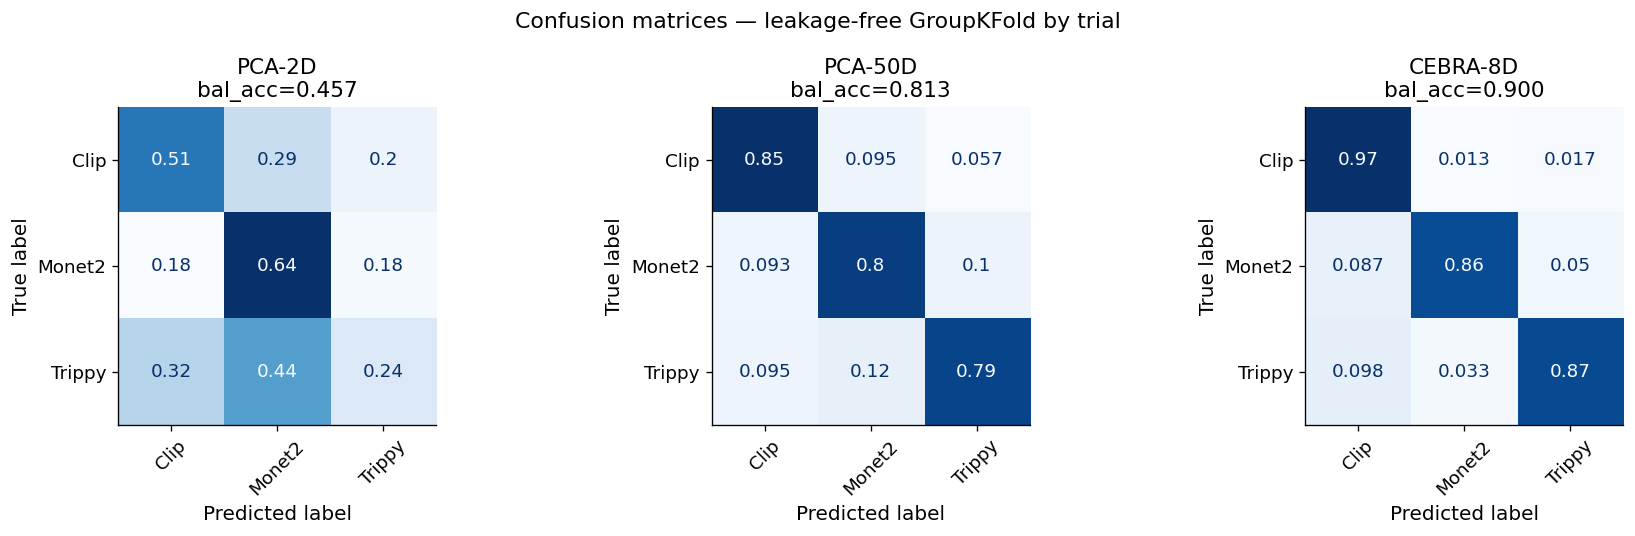

In [14]:
# Confusion matrices from leakage-free grouped CV predictions.

fig, axes = plt.subplots(
    1,
    len(predictions),
    figsize=(5 * len(predictions), 4.5),
)

axes = np.atleast_1d(axes)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y, y_pred, normalize='true')

    ConfusionMatrixDisplay(
        cm,
        display_labels=le.classes_,
    ).plot(
        ax=ax,
        colorbar=False,
        cmap='Blues',
        xticks_rotation=45,
    )

    bacc = scores[name][0]
    ax.set_title(f'{name}\nbal_acc={bacc:.3f}')

plt.suptitle('Confusion matrices — leakage-free GroupKFold by trial')
plt.tight_layout()
plt.savefig('fig_ts_confusion_leakage_free.png', dpi=150)
plt.show()


## Shuffle control

Shuffle labels **at the trial level** (so within-trial correlation is
preserved in the null) and re-run the classifier. This is the honest null
for per-bin data.


Real bal_acc      : 0.8125
Null mean ± sd    : 0.3316 ± 0.0250
Null max          : 0.3795
Empirical p       : 0.0000  (N_SHUFFLES=50)


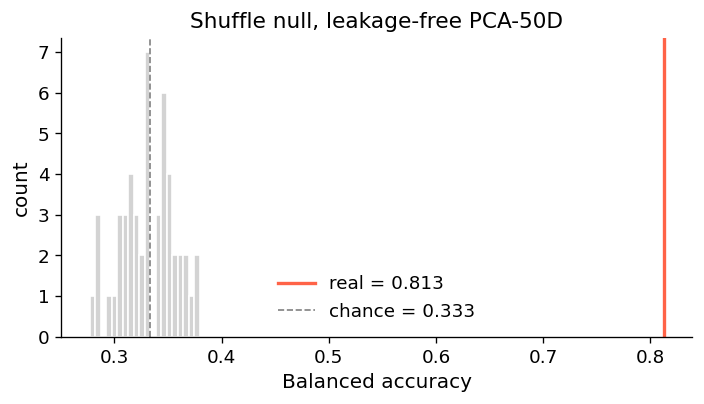

In [15]:
# Trial-level label shuffle control.
# PCA, imputation, scaling, and classifier are all fit inside each CV fold.

unique_trials = np.unique(trial_ids)
trial_to_y = {
    t: y[trial_ids == t][0]
    for t in unique_trials
}

real_bal = scores[f'PCA-{N_PCS_FOR_CLF}D'][0]

null_bal = []
rng_s = np.random.default_rng(SEED)

for i in range(N_SHUFFLES):
    shuffled_y_per_trial = rng_s.permutation(
        [trial_to_y[t] for t in unique_trials]
    )

    t_to_yshuf = dict(zip(unique_trials, shuffled_y_per_trial))
    y_shuf = np.array([t_to_yshuf[t] for t in trial_ids])

    shuffle_model = make_pca_logreg_pipeline(N_PCS_FOR_CLF)

    bal = cross_val_score(
        shuffle_model,
        R_clean,
        y_shuf,
        cv=gkf,
        groups=trial_ids,
        scoring='balanced_accuracy',
        n_jobs=-1,
    ).mean()

    null_bal.append(bal)

null_bal = np.array(null_bal)

print(f'Real bal_acc      : {real_bal:.4f}')
print(f'Null mean ± sd    : {null_bal.mean():.4f} ± {null_bal.std():.4f}')
print(f'Null max          : {null_bal.max():.4f}')

p = (null_bal >= real_bal).mean()
print(f'Empirical p       : {p:.4f}  (N_SHUFFLES={N_SHUFFLES})')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(null_bal, bins=20, color='lightgray', edgecolor='white')
ax.axvline(real_bal, color='tomato', lw=2, label=f'real = {real_bal:.3f}')
ax.axvline(chance_level, color='gray', ls='--', lw=1, label=f'chance = {chance_level:.3f}')
ax.set_xlabel('Balanced accuracy')
ax.set_ylabel('count')
ax.set_title(f'Shuffle null, leakage-free PCA-{N_PCS_FOR_CLF}D')
ax.legend()

plt.tight_layout()
plt.savefig('fig_ts_shuffle_leakage_free.png', dpi=150)
plt.show()

## Within-trial temporal structure

A cheap sanity check that per-bin information is real: colour the PCA
scatter by bin-within-trial. If V1 codes anything stimulus-locked, nearby
bins should sit near each other, and early/late bins should differ.


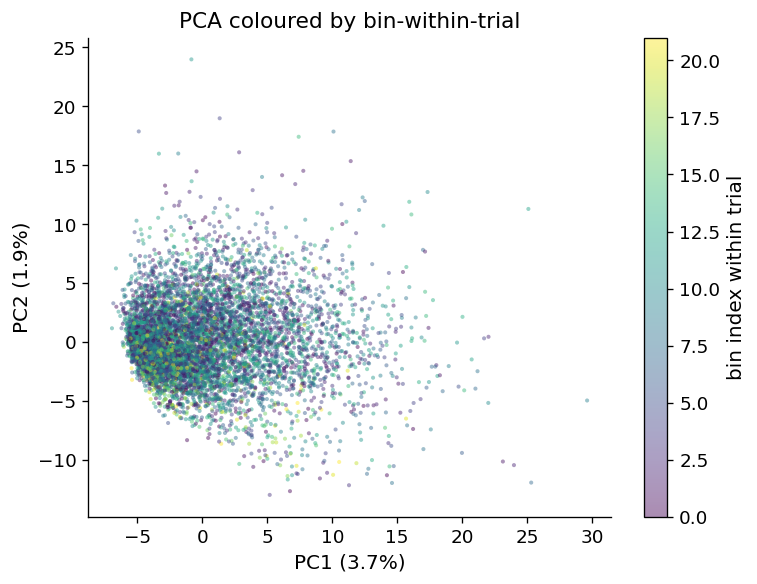

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(R_pca[:,0], R_pca[:,1], c=time_idx, cmap='viridis',
                alpha=0.45, s=6, edgecolors='none')
plt.colorbar(sc, ax=ax, label='bin index within trial')
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax.set_title('PCA coloured by bin-within-trial')
plt.tight_layout(); plt.savefig('fig_ts_pca_by_time.png', dpi=150); plt.show()


## Layer-specific (L4 and L2/3)

Re-run PCA + classifier restricted to each layer. We share the
per-bin sample structure so the only thing that changes is which neurons
the activity matrix is built from.


In [17]:
def run_layer(layer_name, mask):
    R_l = R_clean[:, mask]

    # Per-sample activity filter for this layer.
    act = np.nanstd(R_l, axis=1) > 1e-6

    R_l = R_l[act]
    y_l = y[act]
    tr_l = trial_ids[act]

    layer_gkf = GroupKFold(n_splits=N_CV_SPLITS)
    splits = list(layer_gkf.split(R_l, y_l, groups=tr_l))

    min_train_size = min(len(train_idx) for train_idx, _ in splits)

    n_pc = min(
        N_PCS_FOR_CLF,
        R_l.shape[1],
        min_train_size - 1,
    )

    if n_pc < 1:
        raise ValueError(f'Not enough data/features for PCA in layer {layer_name}')

    model = Pipeline([
        ('impute', SimpleImputer(strategy='mean')),
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=n_pc, random_state=SEED)),
        ('clf', make_logreg()),
    ])

    bal = cross_val_score(
        model,
        R_l,
        y_l,
        cv=splits,
        groups=tr_l,
        scoring='balanced_accuracy',
        n_jobs=-1,
    )

    f1 = cross_val_score(
        model,
        R_l,
        y_l,
        cv=splits,
        groups=tr_l,
        scoring='f1_macro',
        n_jobs=-1,
    )

    return {
        'layer': layer_name,
        'n_neurons': int(mask.sum()),
        'n_samples': int(len(y_l)),
        'n_pcs': int(n_pc),
        'bal_acc': bal.mean(),
        'bal_acc_std': bal.std(),
        'f1': f1.mean(),
        'f1_std': f1.std(),
    }

results = []

for ln in ['L2/3', 'L4', 'L5', 'L6']:
    m = (trusted_meta_clean['layer'] == ln).values

    if m.sum() < 10:
        print(f'Skipping {ln} because it has only {m.sum()} neurons')
        continue

    print(f'Running {ln} ({m.sum()} neurons)...')
    results.append(run_layer(ln, m))

results.append({
    'layer': 'ALL',
    'n_neurons': R_clean.shape[1],
    'n_samples': len(y),
    'n_pcs': N_PCS_FOR_CLF,
    'bal_acc': scores[f'PCA-{N_PCS_FOR_CLF}D'][0],
    'bal_acc_std': scores[f'PCA-{N_PCS_FOR_CLF}D'][1],
    'f1': scores[f'PCA-{N_PCS_FOR_CLF}D'][2],
    'f1_std': scores[f'PCA-{N_PCS_FOR_CLF}D'][3],
})

df_layer = pd.DataFrame(results)

print('\nLayer-wise leakage-free results:')
print(df_layer.to_string(index=False))

Running L2/3 (220 neurons)...


Running L4 (257 neurons)...


Running L5 (89 neurons)...


Running L6 (12 neurons)...

Layer-wise leakage-free results:
layer  n_neurons  n_samples  n_pcs  bal_acc  bal_acc_std       f1   f1_std
 L2/3        220       7520     50 0.722269     0.020079 0.639449 0.018001
   L4        257       7520     50 0.728824     0.036947 0.634594 0.031183
   L5         89       7520     50 0.576662     0.038316 0.472412 0.030356
   L6         12       7515     12 0.505991     0.015581 0.402156 0.009082
  ALL        579       7520     50 0.812519     0.021206 0.740105 0.021323


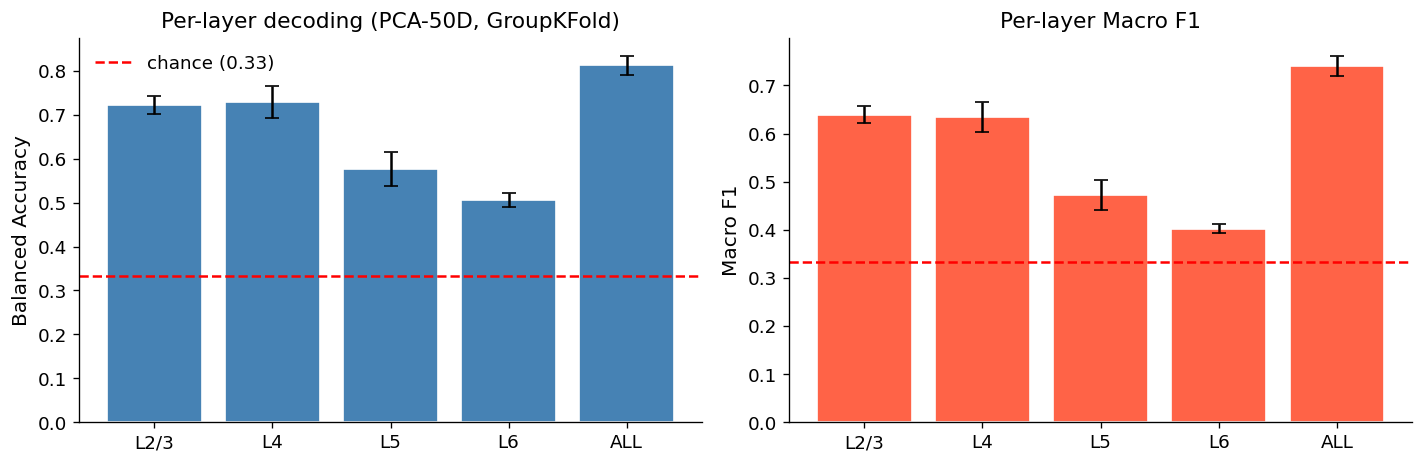

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(df_layer))
axes[0].bar(x, df_layer['bal_acc'], yerr=df_layer['bal_acc_std'],
            color='steelblue', edgecolor='white', capsize=4)
axes[0].axhline(chance_level, color='red', ls='--', label=f'chance ({chance_level:.2f})')
axes[0].set_xticks(x); axes[0].set_xticklabels(df_layer['layer'])
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title(f'Per-layer decoding (PCA-{N_PCS_FOR_CLF}D, GroupKFold)')
axes[0].legend()

axes[1].bar(x, df_layer['f1'], yerr=df_layer['f1_std'],
            color='tomato', edgecolor='white', capsize=4)
axes[1].axhline(chance_level, color='red', ls='--')
axes[1].set_xticks(x); axes[1].set_xticklabels(df_layer['layer'])
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Per-layer Macro F1')

plt.tight_layout(); plt.savefig('fig_ts_layers.png', dpi=150); plt.show()


## Summary

- Every temporal bin is an individual sample → temporal structure is
  retained and the sample count is large enough for non-linear DR to
  behave.
- Classifier is evaluated in PCA-50 space, not in a 2-D embedding.
- Cross-validation is `GroupKFold(groups=trial_ids)`, so the model can
  never see another bin from the same trial during training.
- The shuffle null shuffles labels at the **trial** level, which is the
  honest null when within-trial bins are correlated.
- Layer-restricted versions reuse the per-bin/grouped-CV pipeline.

If decoding is still around chance in PCA-50 space with grouped CV, the
conclusion is that V1 population mean rate (even with time preserved at
~5-frame resolution) doesn't separate these *coarse stimulus categories*
on this session — and the next experiment to try is decoding **specific
stimulus identity** within a category (e.g. clip-ID, or grating
orientation for the Monet subset).
